# CLIP + SAM

## NOTE: works a lot faster with a gpu, i've been running with a T4 in google colab

In [38]:
import cv2
from segment_anything import build_sam, SamAutomaticMaskGenerator,sam_model_registry, SamPredictor
from PIL import Image, ImageDraw
import clip
import torch
import numpy as np

In [40]:
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"
CHECKPOINT_PATH = "sam_vit_h_4b8939.pth"

In [ ]:
# Download the model weights to load them here
# mask_generator = SamAutomaticMaskGenerator(build_sam(checkpoint="sam_vit_h_4b8939.pth"))

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=DEVICE)
mask_generator = SamAutomaticMaskGenerator(sam)


c:\Users\peter\AppData\Local\Programs\Python\Python312\Lib\site-packages\segment_anything\build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.

In [44]:
image_path = "assets/image1.jpg"

In [ ]:
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
masks = mask_generator.generate(image)

In [5]:
def convert_box_xywh_to_xyxy(box):
    x1 = box[0]
    y1 = box[1]
    x2 = box[0] + box[2]
    y2 = box[1] + box[3]
    return [x1, y1, x2, y2]

In [15]:
def segment_image(image, segmentation_mask):
    image_array = np.array(image)
    segmented_image_array = np.zeros_like(image_array)
    segmented_image_array[segmentation_mask] = image_array[segmentation_mask]
    segmented_image = Image.fromarray(segmented_image_array)
    black_image = Image.new("RGB", image.size, (0, 0, 0))
    transparency_mask = np.zeros_like(segmentation_mask, dtype=np.uint8)
    transparency_mask[segmentation_mask] = 255
    transparency_mask_image = Image.fromarray(transparency_mask, mode='L')
    black_image.paste(segmented_image, mask=transparency_mask_image)
    return black_image

In [31]:
# Cut out all masks
image = Image.open(image_path)
cropped_boxes = []

for mask in masks:
    cropped_boxes.append(segment_image(image, mask["segmentation"]).crop(convert_box_xywh_to_xyxy(mask["bbox"])))

In [8]:
# Load CLIP
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, preprocess = clip.load("ViT-B/32", device=device)

100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 106MiB/s]


In [9]:
@torch.no_grad()
def retriev(elements: list[Image.Image], search_text: str) -> int:
    preprocessed_images = [preprocess(image).to(device) for image in elements]
    tokenized_text = clip.tokenize([search_text]).to(device)
    stacked_images = torch.stack(preprocessed_images)
    image_features = model.encode_image(stacked_images)
    text_features = model.encode_text(tokenized_text)
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)
    probs = 100. * image_features @ text_features.T
    return probs[:, 0].softmax(dim=0)

In [10]:
def get_indices_of_values_above_threshold(values, threshold):
    return [i for i, v in enumerate(values) if v > threshold]

In [ ]:
scores = retriev(cropped_boxes, "dirty")

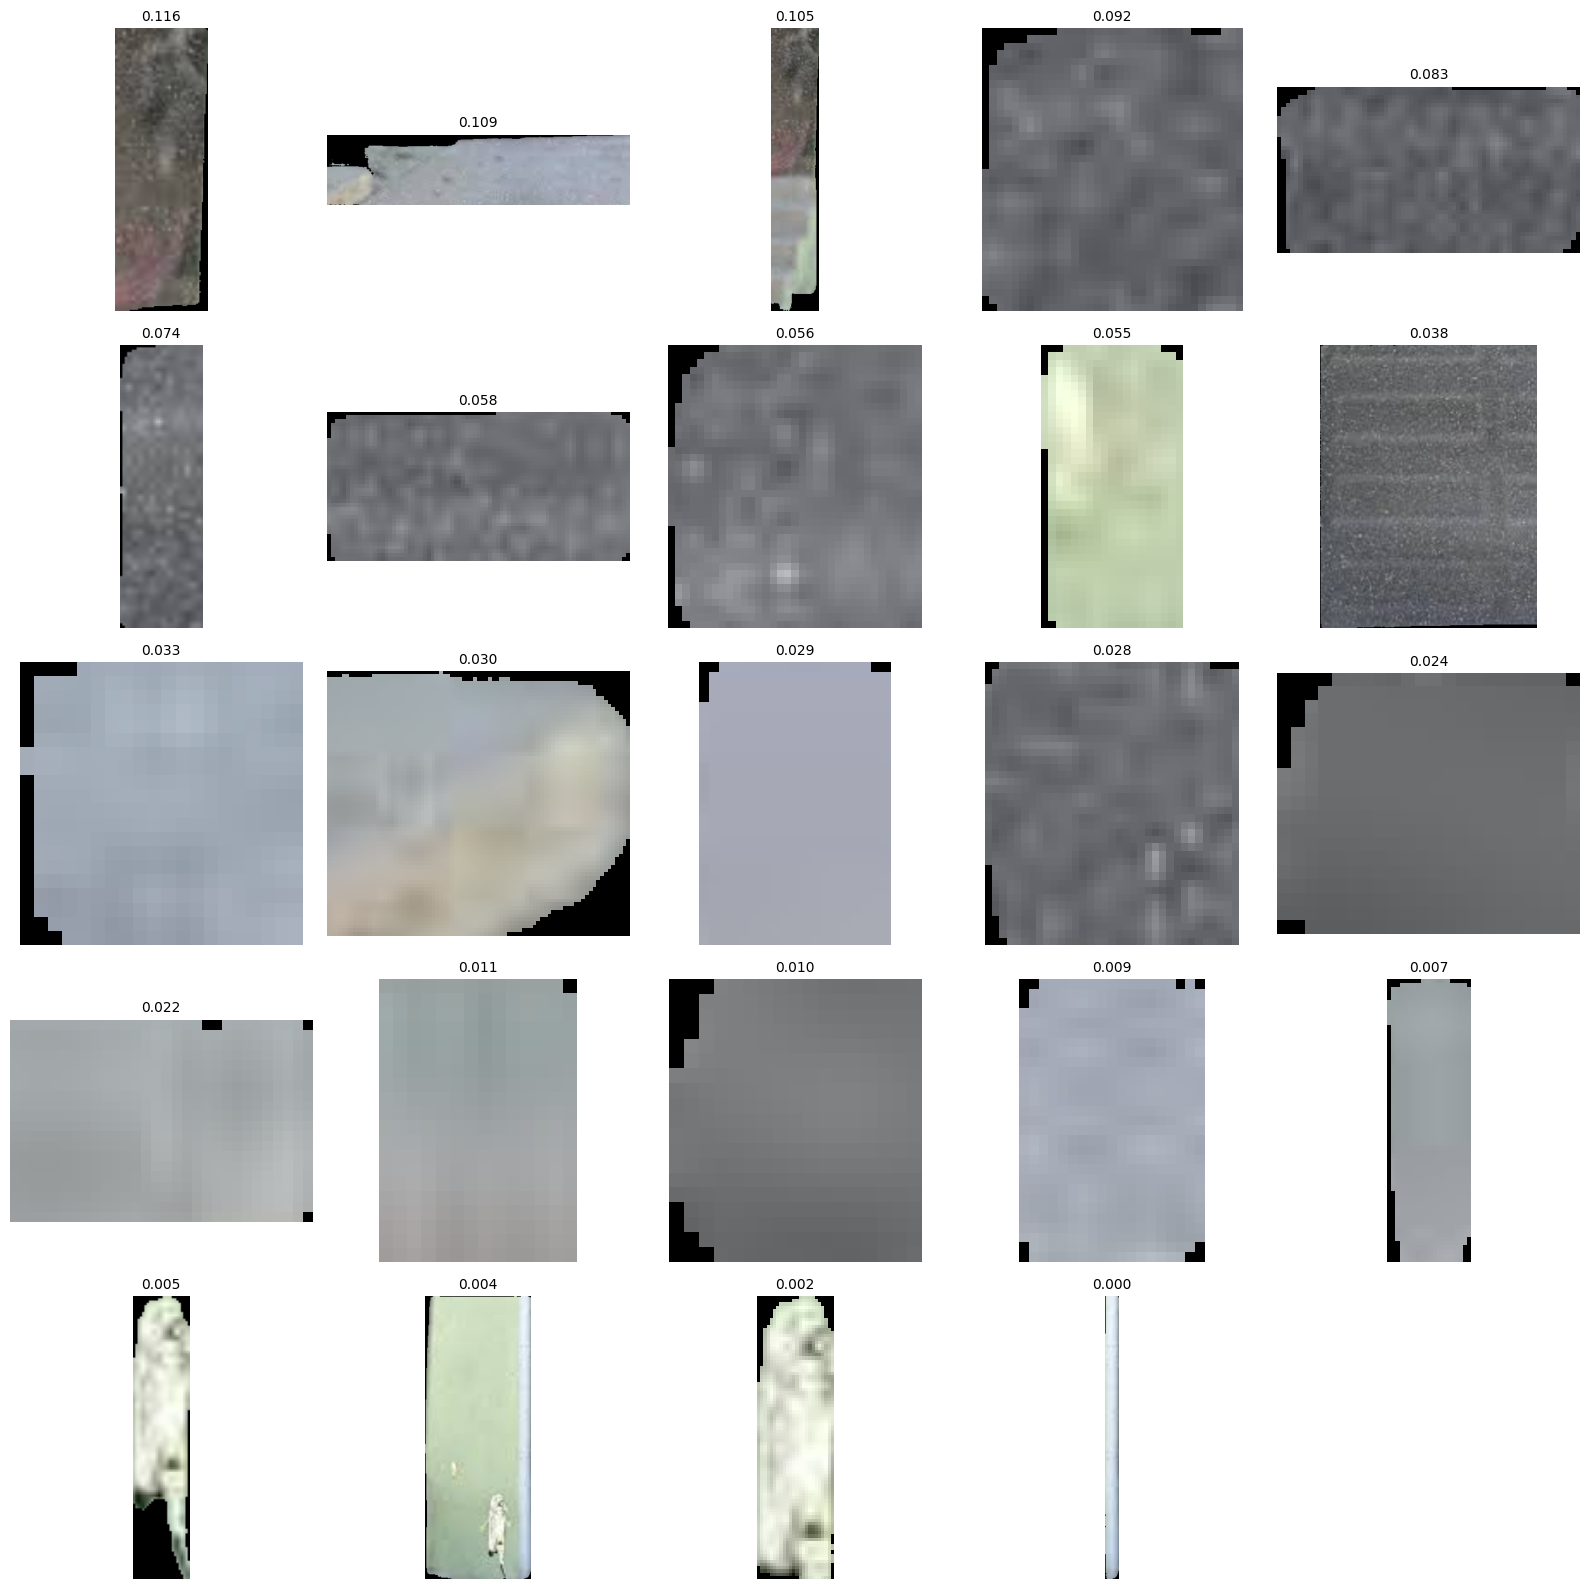

In [46]:
import matplotlib.pyplot as plt
from math import ceil

# Sort masks by score
sorted_indices = torch.argsort(scores, descending=True).tolist()

# Choose how many top masks to show
TOP_K = 25
top_k_indices = sorted_indices[:TOP_K]

# Prepare grid
n_cols = 5
n_rows = ceil(TOP_K / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 16))
axes = axes.flatten()

for ax_idx, mask_idx in enumerate(top_k_indices):
    ax = axes[ax_idx]
    
    # Option 1: Show the cropped box (recommended)
    img = cropped_boxes[mask_idx]

    # Option 2: Show the raw mask
    # img = Image.fromarray(masks[mask_idx]["segmentation"].astype('uint8') * 255)

    # Option 3: Overlay original + mask
    # seg = masks[mask_idx]["segmentation"]
    # overlay = image.copy()
    # overlay_np = np.array(overlay)
    # overlay_np[~seg] = 0
    # img = Image.fromarray(overlay_np)

    ax.imshow(img)
    ax.set_title(f"{scores[mask_idx].item():.3f}", fontsize=10)
    ax.axis("off")

# Hide empty axes
for ax in axes[len(top_k_indices):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

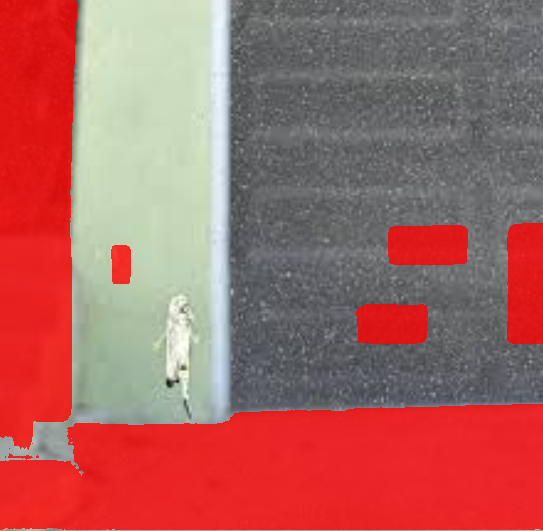

In [ ]:
indices = get_indices_of_values_above_threshold(scores, 0.10)

# Select just top
# best_idx = scores.argmax().item()
# indices = [best_idx]

segmentation_masks = []

for seg_idx in indices:
    segmentation_mask_image = Image.fromarray(masks[seg_idx]["segmentation"].astype('uint8') * 255)
    segmentation_masks.append(segmentation_mask_image)

original_image = Image.open(image_path)
overlay_image = Image.new('RGBA', image.size, (0, 0, 0, 0))
overlay_color = (255, 0, 0, 200)

draw = ImageDraw.Draw(overlay_image)
for segmentation_mask_image in segmentation_masks:
    draw.bitmap((0, 0), segmentation_mask_image, fill=overlay_color)

result_image = Image.alpha_composite(original_image.convert('RGBA'), overlay_image)
result_image